In [1]:
import sys
import os
import gc
import pandas as pd
import joblib
import matplotlib.pyplot as plt

#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

20

In [2]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------

# star["u_g"] = star["u"] - star["g"]
# star["g_r"] = star["g"] - star["r"]
# star["r_i"] = star["r"] - star["i"]
# star["i_z"] = star["i"] - star["z"]

# star.info()


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

In [3]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


Outliers removed: 9,400 rows  (90,600 remain)
X_train shape: (54360, 10)
X_val shape: (18120, 10)
X_test shape: (18120, 10)


In [4]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")

DataLoaders created.


In [5]:
# Train and evaluate traditional ML models
models = sc.train_traditional(X_train, y_train, X_val, y_val)


Linear SVC trained.
  [Training] Acc=94.41%  P=0.93  R=0.91  F1=0.92
  [Validation] Acc=94.40%  P=0.92  R=0.91  F1=0.92
Decision Tree trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=96.27%  P=0.93  R=0.94  F1=0.94
Random Forest trained.
  [Training] Acc=99.99%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=97.68%  P=0.97  R=0.95  F1=0.96
CatBoost trained.
  [Training] Acc=98.87%  P=0.99  R=0.97  F1=0.98
  [Validation] Acc=97.32%  P=0.96  R=0.95  F1=0.96
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 54360, number of used features: 10
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (0.62 MB) transferred to GPU in 0.001132 secs. 0

In [6]:

if os.path.exists('trained_models/stacking_clf_NOsmote.pkl'):
    stacking_clf = joblib.load('trained_models/stacking_clf_NOsmote.pkl')
    print("Stacking Classifier caricato da disco")
else:
    stacking_clf = sc.train_stacking(X_train, y_train, X_val, y_val, n_jobs=2)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(stacking_clf, 'trained_models/stacking_clf_NOsmote.pkl')
    print("Stacking Classifier trained and saved")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000826 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 54360, number of used features: 10
[LightGBM] [Info] Start training from score -0.426857
[LightGBM] [Info] Start training from score -2.206874
[LightGBM] [Info] Start training from score -1.438014
starting training...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001952 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 43488, number of used features: 10
[LightGBM] [Info] Start training from score -0.426836
[LightGBM] [Info] Start training from score -2.206999
[LightGBM] [Info] Start training from score -1.438014
[LightGBM] [I

In [7]:
if os.path.exists('trained_models/voting_clf_NOsmote.pkl'):
    voting_clf = joblib.load('trained_models/voting_clf_NOsmote.pkl')
    print("Voting Classifier caricato da disco")
else:
    voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(voting_clf, 'trained_models/voting_clf_NOsmote.pkl')
    print("Voting Classifier trained and saved")

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 54360, number of used features: 10
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 10 dense feature groups (0.62 MB) transferred to GPU in 0.001286 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -0.426857
[LightGBM] [Info] Start training from score -2.206874
[LightGBM] [Info] Start training from score -1.438014
Voting Classifier trained.
  [Training] Acc=99.20%  P=0.99  R=0.98  F1=0.99
  [Validation] Acc=97.58%  P=0.97  R=0.95  F1=0.96
Voting Classifier trained and saved


In [8]:
import torch
from stellar_classification.models.network import SimpleNN

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

if os.path.exists('trained_models/nn_model_NOsmote.pth'):
    nn_model = SimpleNN(input_size, num_classes)
    nn_model.load_state_dict(torch.load('trained_models/nn_model_NOsmote.pth'))
    nn_model.eval()
    print("NN caricata da disco")
else:
    nn_model = sc.train_neural( 
        train_loader=train_loader,
        val_loader=val_loader,
        input_size=input_size,
        num_classes=num_classes,
        num_epochs=10,
        lr=0.001
    )
    torch.save(nn_model.state_dict(), 'trained_models/nn_model_NOsmote.pth')
    print("NN trained nad saved")

Epoch  1/10  loss=0.2998  val_acc=94.16%
Epoch  2/10  loss=0.1669  val_acc=95.32%
Epoch  3/10  loss=0.1460  val_acc=95.92%
Epoch  4/10  loss=0.1353  val_acc=96.09%
Epoch  5/10  loss=0.1287  val_acc=96.09%
Epoch  6/10  loss=0.1242  val_acc=96.13%
Epoch  7/10  loss=0.1208  val_acc=96.46%
Epoch  8/10  loss=0.1177  val_acc=96.35%
Epoch  9/10  loss=0.1152  val_acc=96.46%
Epoch 10/10  loss=0.1136  val_acc=96.48%
NN trained nad saved


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

y_test_pred_stacking = stacking_clf.predict(X_test)
stacking_metrics = sc.evaluate_test_set(y_test, y_test_pred_stacking, "Stacking Classifier")
sc.print_metrics(stacking_metrics)
    
nn_metrics = sc.evaluate_neural(test_loader, nn_model, device, "Neural Network")
sc.print_metrics(nn_metrics)



Voting Classifier:
  Accuracy  : 97.72%
  Precision: 0.9702
  Recall   : 0.9501
  F1       : 0.9595
  Confusion Matrix:
[[11686   109    29]
 [  275  1719     0]
 [    1     0  4301]]

Stacking Classifier:
  Accuracy  : 97.78%
  Precision: 0.9715
  Recall   : 0.9504
  F1       : 0.9603
  Confusion Matrix:
[[11698   105    21]
 [  274  1720     0]
 [    3     0  4299]]

Neural Network:
  Accuracy  : 96.61%
  Precision: 0.9563
  Recall   : 0.9394
  F1       : 0.9472
  Confusion Matrix:
[[11552   125   147]
 [  293  1699     2]
 [   47     0  4255]]


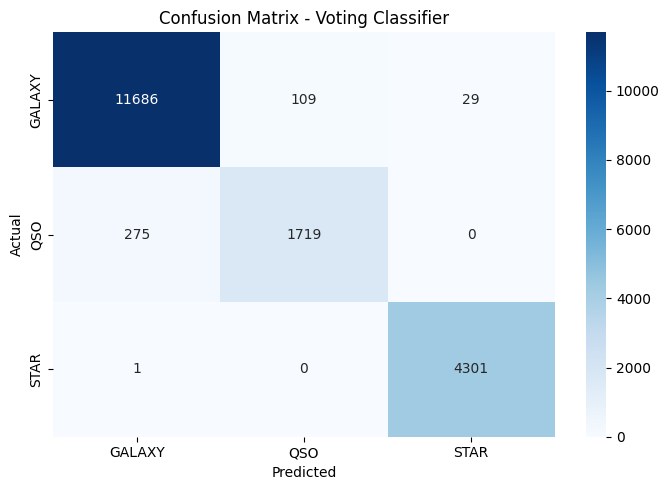

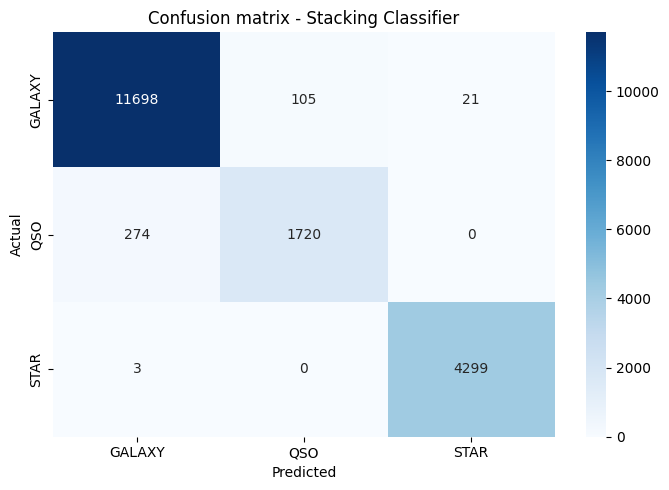

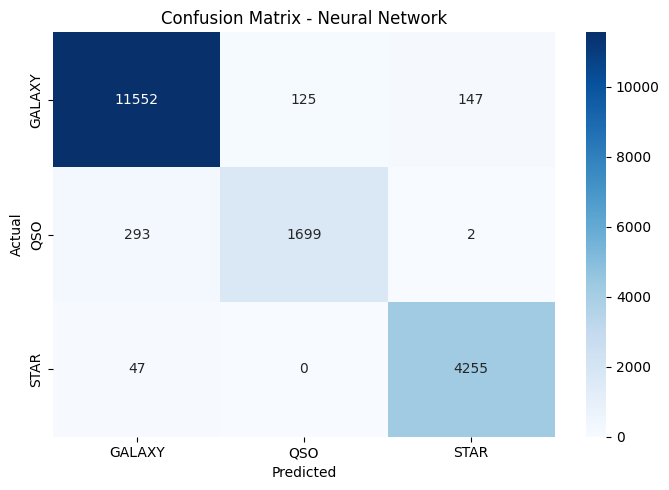

In [10]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier')
sc.plot_confusion_matrix(stacking_metrics['confusion_matrix'], class_names=class_names, title='Confusion matrix - Stacking Classifier')
sc.plot_confusion_matrix(nn_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Neural Network')


1 batch shape: 4000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 54360, number of used features: 10
[LightGBM] [Info] Start training from score -0.426857
[LightGBM] [Info] Start training from score -2.206874
[LightGBM] [Info] Start training from score -1.438014
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2120
[array([-0.0007 , -0.0005 ,  0.0266 ,  0.0466 ,  0.00185,  0.00265,
        0.0134 ,  0.4459 ,  0.00685, -0.0005 ]), array([3.0000e-04, 1.1500e-03, 2.3700e-02, 4.6800e-02, 2.1500e-03,
       6.3500e-03, 1.6400e-02, 4.5755e-01, 6.7500e-03, 1.7000e-03]), array([ 1.00000000e-04, -6.66133815e-17,  2.61500000e-02,  4.78500000e-02,
        1.40000000e-03,  4.50000000e-03,  1.38000000e-02,  4.43950000e-01,
        5.60000000e-03,  2.50000000e-04]), arr

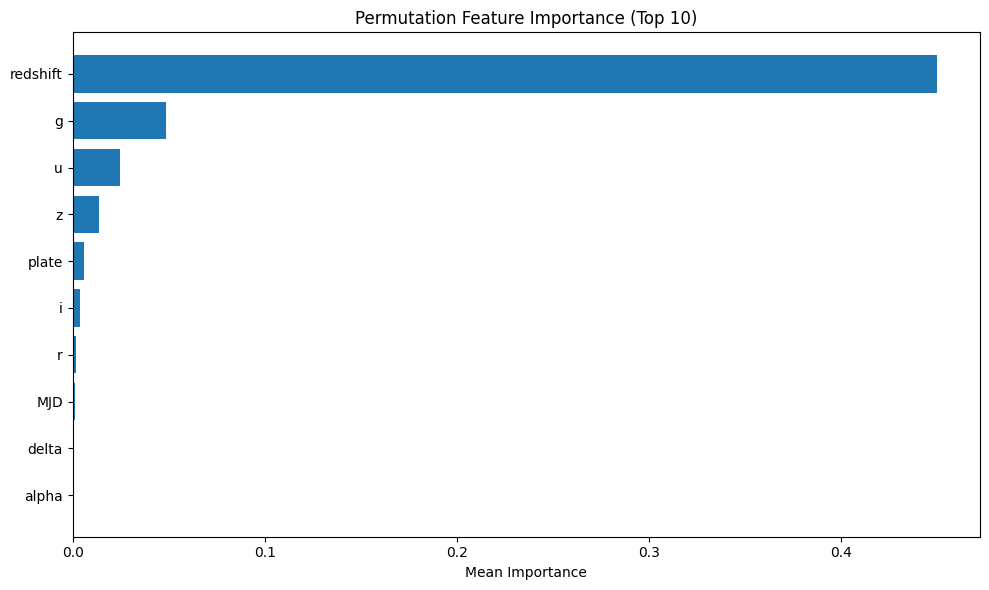

Feature Importance Scores:
redshift: 0.4498
g: 0.0486
u: 0.0248
z: 0.0139
plate: 0.0059
i: 0.0040
r: 0.0018
MJD: 0.0010
delta: 0.0006
alpha: 0.0003
1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2120
[array([ 4.0000e-04,  1.1500e-03,  2.5500e-02,  4.9150e-02,  1.5500e-03,
        5.9000e-03,  1.7450e-02,  4.5295e-01,  5.3000e-03, -3.0000e-04]), array([-0.0007 , -0.00065,  0.02235,  0.03795, -0.0005 ,  0.0046 ,
        0.01675,  0.45925,  0.0029 , -0.00135]), array([-9.5000e-04,  2.5000e-04,  2.4750e-02,  4.4950e-02,  7.0000e-04,
        4.2500e-03,  1.4900e-02,  4.4615e-01,  2.8000e-03,  6.0000e-04]), array([0.0006 , 0.0007 , 0.0257 , 0.0433 , 0.00125, 0.00395, 0.01485,
       0.4657 , 0.0038 , 0.0009 ]), array([-4.71698113e-04,  5.66037736e-04,  2.33018868e-02,  5.52830189e-02,
       -2.83018868e-04,  5.37735849e-03,  1.37735849e-02,  4.47169811e-01,
        2.83018868e-03,  9.43396226e-05])]


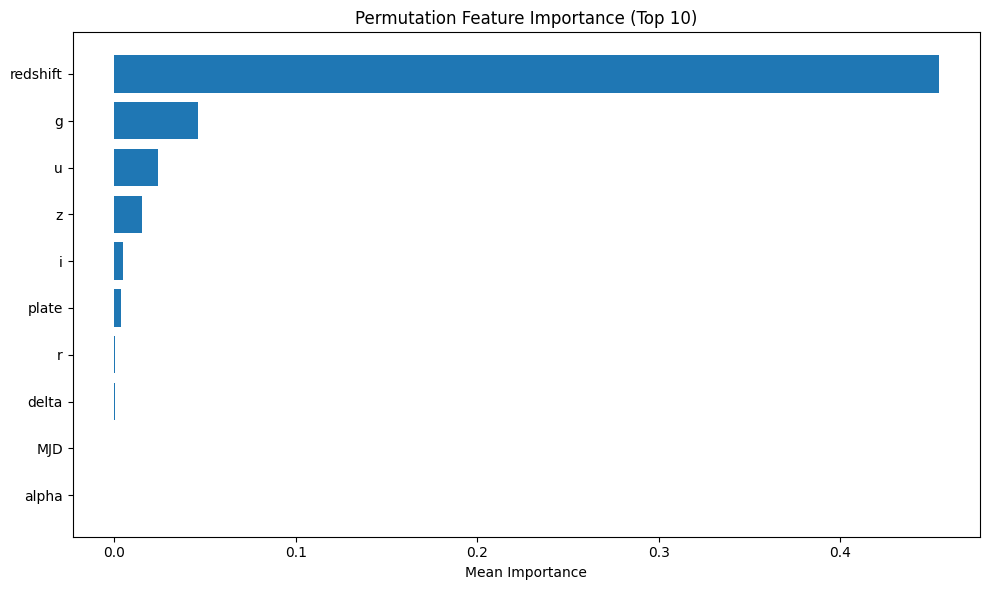

Feature Importance Scores:
redshift: 0.4542
g: 0.0461
u: 0.0243
z: 0.0155
i: 0.0048
plate: 0.0035
r: 0.0005
delta: 0.0004
MJD: -0.0000
alpha: -0.0002


In [11]:
imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")

imp = sc.compute_permutation_importance(stacking_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}") 



In [27]:
def classify(index):

    res = stacking_clf.predict(star[index])
    classes = {0:'Galasy', 1:'Quasar', 2:'Star'}
    return classes[res[0]]



In [28]:
classify(11111)

KeyError: 11111

In [30]:
print(star.type())

AttributeError: 'DataFrame' object has no attribute 'type'